#Lab0_exercises- Fredda Nyarko

"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""


#Task 1

In [38]:
import numpy as np

In [39]:
A = np.ones((5, 5))
A[1:4,1:4] = 0
print(A)



[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


#Task 2

In [40]:
np.random.seed(42)
data = np.random.randn(100, 3)
normalized = (data - data.mean(axis=0)) / data.std(axis=0)
print(normalized.mean(axis=0))
print(normalized.std(axis=0))

[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
[1. 1. 1.]


#Task 3

In [41]:
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print(f"  Estimated  : {theta_hat}")
print(f"  True theta : {true_theta}")
print(f"  Difference : {(theta_hat - true_theta)}")

  Estimated  : [ 2.51723721 -1.19783796  3.72399266]
  True theta : [ 2.5 -1.2  3.7]
  Difference : [0.01723721 0.00216204 0.02399266]


"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""


In [42]:
import pandas as pd
import numpy as np

In [43]:
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

#Task 1

In [44]:
#Display basic information about the dataset
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

#Identify and count missing values
print(df.isnull().sum())

# Fill missing exam_score with the mean score for the student's
df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)
# Fill missing hours_studied with the median for that student's year
df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median')
)

print(df.isnull().sum())


   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.042336
4        1004  Physics     4   93.657745                      6      15.287370
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes

#Task 2

In [45]:
#Calculate and display the average exam_score by major
avg_by_major = df.groupby('major')['exam_score'].mean()
print(avg_by_major)

#Find the major with the highest average exam_score
best_major = avg_by_major.idxmax()
print(f"\nBest performing major: {best_major}")

#Calculate the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])
print(correlation)

#Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)

def performance(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(performance)

df.head()

major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Best performing major: CS
-0.055981383472924404


,student_id,major,year,exam_score,assignments_completed,hours_studied,performance
0,1000,Physics,3,68.199753,10,14.031175,Needs Improvement
1,1001,Biology,4,77.322537,9,12.204873,Average
2,1002,CS,3,77.930725,9,7.829556,Average
3,1003,Physics,1,67.856486,2,14.042336,Needs Improvement
4,1004,Physics,4,93.657745,6,15.287370,Excellent


#Task 3

In [46]:
#For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied

major_year = df.groupby(['major', 'year']).agg(
    num_students    = ('student_id',   'count'),
    avg_exam_score  = ('exam_score',   'mean'),
    avg_hours       = ('hours_studied','mean')
)
print(major_year)

# Identify top 5 students based on exam_score (handle ties appropriately)
top5 = df.sort_values('exam_score', ascending=False).head(5)
print(top5)

#Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print(pivot)

              num_students  avg_exam_score  avg_hours
major   year                                         
Biology 1               13       76.570059  12.677806
        2               12       74.899613  13.426372
        3               14       80.178476  14.486815
        4               15       70.697689  14.253944
CS      1               12       77.098194  13.039480
        2                7       76.155936  13.995784
        3                9       72.347626  15.039892
        4               18       78.119997  16.275541
Math    1               11       74.053167  19.001215
        2                9       81.226714  12.345468
        3               10       72.017537  15.175871
        4               16       73.103066  17.419175
Physics 1               13       77.828686  13.489911
        2               12       73.277734  14.616778
        3               17       73.134319  14.199901
        4               12       78.130194  15.550491
     student_id    major  ye

"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

#Task 1

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_7572/2256551664.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='major', y='exam_score', ax=ax2, palette='Set2')


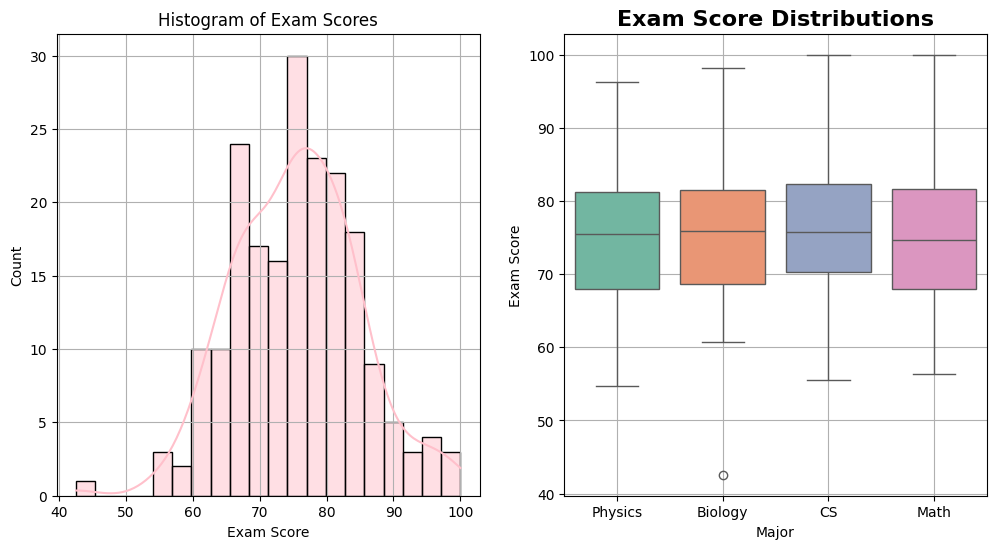

In [48]:
#Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12, 6))
#left
sns.histplot(df['exam_score'], kde=True, ax=ax1, color='pink', bins=20)
ax1.set_title('Histogram of Exam Scores')
ax1.set_xlabel('Exam Score')
ax1.set_ylabel('Count')
ax1.grid(True)

#right
sns.boxplot(data=df, x='major', y='exam_score', ax=ax2, palette='Set2')
ax2.set_title('Exam Scores by Major')
ax2.set_xlabel('Major')
ax2.set_ylabel('Exam Score')
ax2.grid(True)

plt.title('Exam Score Distributions', fontsize=16, fontweight='bold')
plt.show()


#Task 2

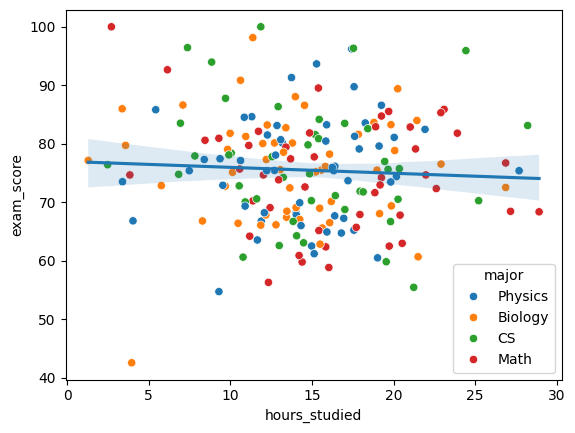

In [49]:
#Create a scatter plot of hours_studied vs exam_score
sns.scatterplot(data = df, x='hours_studied', y = 'exam_score', hue = 'major')
sns.regplot(data=df, x='hours_studied', y='exam_score', scatter = False)

plt.show()

#Task 3

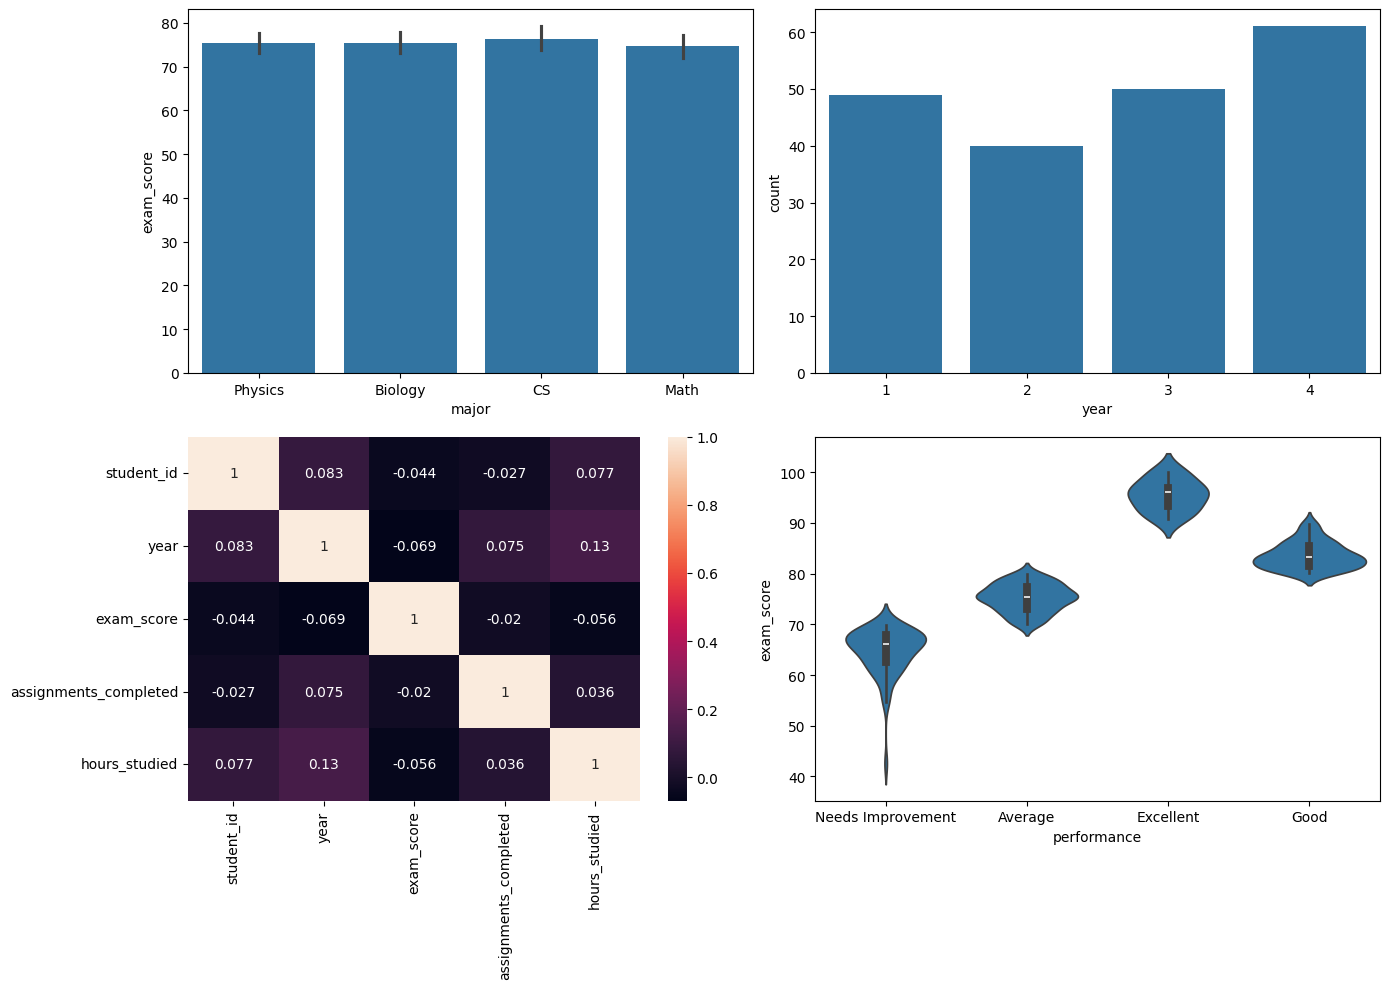

In [53]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))
sns.barplot(data=df, x='major', y='exam_score', ax=ax[0,0])
sns.countplot(data=df, x='year', ax=ax[0,1])
sns.heatmap(df.corr(numeric_only=True), annot=True, ax=ax[1,0])
sns.violinplot(data=df, x='performance', y='exam_score', ax=ax[1,1])

plt.tight_layout()
plt.show()


"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

In [55]:
np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

customers.head()

,age,income,purchase_frequency,avg_purchase_value
0,56,92443.123940,7,94.527456
1,69,70649.305211,2,100.932279
2,46,19612.600681,3,79.699876
3,32,40315.318543,2,130.137787
4,60,75338.222984,8,102.904845


In [56]:
max_freq = customers['purchase_frequency'].max()

customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)

customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

customers.head()

,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV
0,56,92443.123940,7,94.527456,0.416667,937.397271
1,69,70649.305211,2,100.932279,0.833333,370.085023
2,46,19612.600681,3,79.699876,0.750000,418.424348
3,32,40315.318543,2,130.137787,0.833333,477.171887
4,60,75338.222984,8,102.904845,0.333333,1097.651683


In [57]:
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70']
)

customers.head()

,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV,age_group
0,56,92443.123940,7,94.527456,0.416667,937.397271,51-70
1,69,70649.305211,2,100.932279,0.833333,370.085023,51-70
2,46,19612.600681,3,79.699876,0.750000,418.424348,36-50
3,32,40315.318543,2,130.137787,0.833333,477.171887,26-35
4,60,75338.222984,8,102.904845,0.333333,1097.651683,51-70


In [58]:
summary = customers.groupby('age_group').agg({
    'income': 'mean',
    'CLV': ['mean', 'sum'],
    'age': 'count'
})

summary

/tmp/ipykernel_7572/2117073004.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = customers.groupby('age_group').agg({


income         CLV                  age
                   mean        mean            sum count
age_group                                               
18-25      51805.879852  704.492597   48609.989225    69
26-35      48747.148046  747.738562   54584.915035    73
36-50      48516.895668  732.796612  117247.457917   160
51-70      50713.163384  762.693498  141860.990683   186

In [59]:
top_customers = customers[customers['CLV'] >= customers['CLV'].quantile(0.9)]

top_customers

,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV,age_group
6,38,58876.388563,10,110.331527,0.166667,1287.201143,36-50
9,40,48809.492879,10,110.228581,0.166667,1286.000108,36-50
19,41,21282.756976,8,119.651218,0.333333,1276.279663,36-50
24,38,53981.193911,8,120.320786,0.333333,1283.421714,36-50
57,64,45956.146951,7,135.470585,0.416667,1343.416638,51-70
60,25,66508.326980,7,142.042870,0.416667,1408.591795,18-25
76,61,62482.396341,7,127.841352,0.416667,1267.760075,51-70
79,53,32054.912570,10,108.862819,0.166667,1270.066217,51-70
82,65,69502.394668,10,117.589989,0.166667,1371.883208,51-70
86,40,58258.629086,8,127.048701,0.333333,1355.186147,36-50


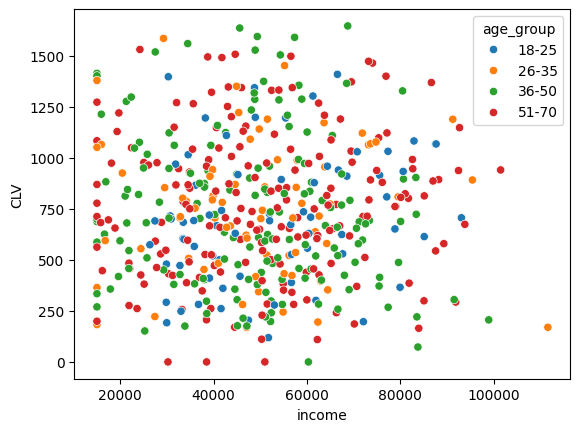

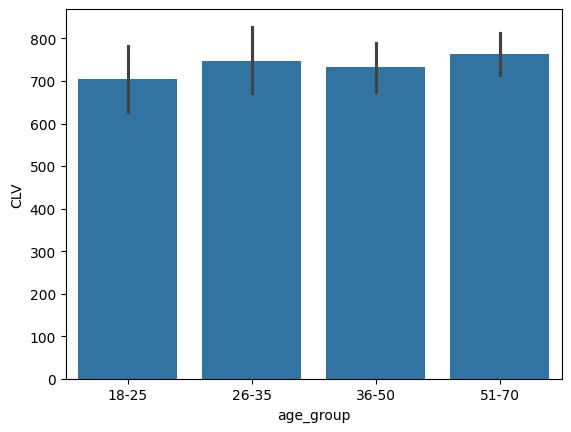

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=customers, x='income', y='CLV', hue='age_group')
plt.show()

sns.barplot(data=customers, x='age_group', y='CLV')
plt.show()